<a href="https://colab.research.google.com/github/sleepyarya/PCVK-SMT5/blob/main/Week%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tugas 1: Inverse Citra


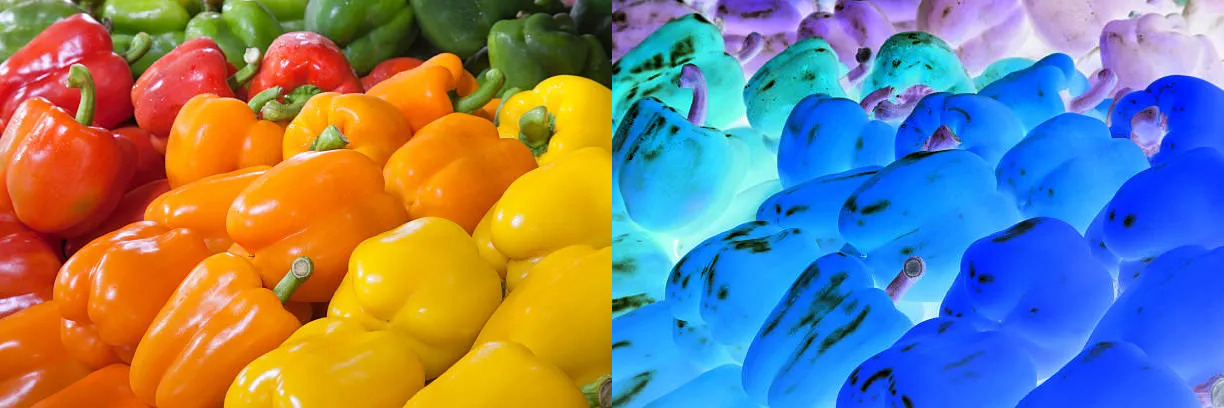

In [6]:
# 1. Inverse Citra
img_peppers = cv.imread('/content/perfect-peppers.jpg')

if img_peppers is not None:
    inv_peppers = 255 - img_peppers
    print('Tugas 1: Inverse Citra')
    cv2_imshow(np.hstack((img_peppers, inv_peppers)))
else:
    print('File perfect-peppers.jpg tidak ditemukan')

Masukkan tingkat kecerahan (misal 10): 10
Masukkan kontras (misal 1.5 atau 50): 1.5
Tugas 2: Transformasi Contrast & Brightness


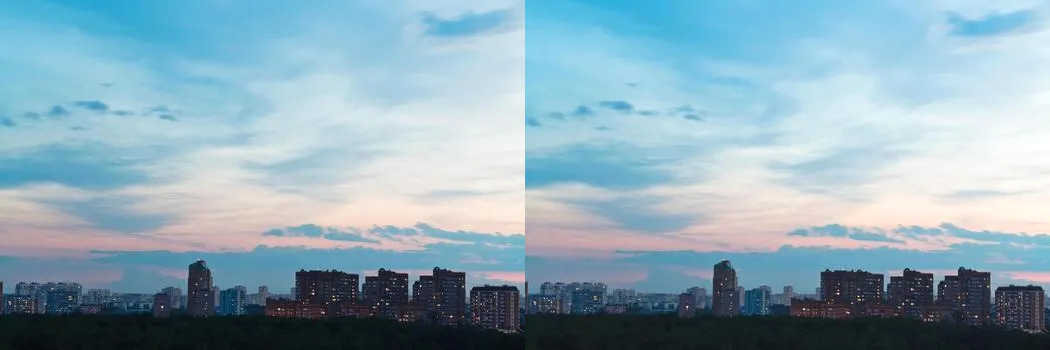

In [8]:
# 2. Transformasi Contrast & Brightness
# Ganti dengan nama file sky/pemandangan kamu
img_sky = cv.imread('/content/durk-blue-and-pink-night-sky-over-city-photo.jpg')

if img_sky is None:
    print("Gambar tidak ditemukan, cek nama file lengkapnya di sidebar Files.")
else:
    try:
        brightness = int(input('Masukkan tingkat kecerahan (misal 10): '))
        contrast = float(input('Masukkan kontras (misal 1.5 atau 50): '))

        # Hitung faktor pengali kontras (F)
        factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

        # Aplikasi rumus & truncate menggunakan np.clip (0-255)
        contrast_img = factor * (img_sky.astype(float) - 128) + 128 + brightness
        contrast_img = np.clip(contrast_img, 0, 255).astype(np.uint8)

        print('Tugas 2: Transformasi Contrast & Brightness')
        cv2_imshow(np.hstack((img_sky, contrast_img)))
    except ValueError:
        print('Error: Nilai input harus berupa angka.')

Masukkan nilai kecerahan: 50
Tugas 3: Transformasi Logarithmic Brightness


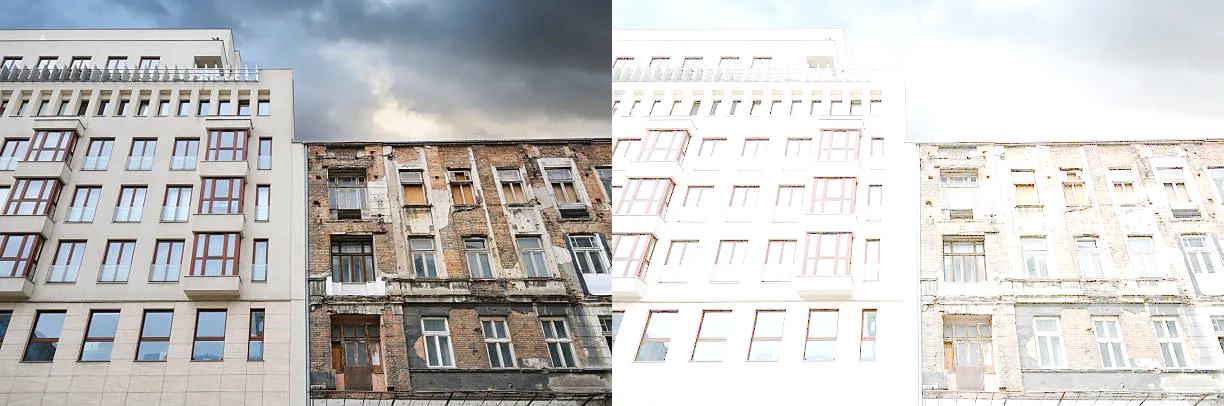

In [10]:
# 3. Logarithmic Brightness
img_building = cv.imread('/content/buildings-century-apart.jpg')

if img_building is not None:
    try:
        # Meminta input nilai kecerahan dari pengguna (misal: 50)
        c = float(input('Masukkan nilai kecerahan: '))

        # Konversi ke float64 sebelum operasi matematika agar tidak overflow
        img_float = img_building.astype(np.float64)

        # Formula Transformasi Log: s = c * log(1 + r)
        log_img = c * np.log(1.0 + img_float)

        # Truncate nilai piksel agar berada di rentang 0-255
        log_img = np.clip(log_img, 0, 255).astype(np.uint8)

        print('Tugas 3: Transformasi Logarithmic Brightness')
        cv2_imshow(np.hstack((img_building, log_img)))
    except ValueError:
        print("Error: Input harus berupa angka.")
else:
    print("Gambar buildings-century-apart.jpg tidak ditemukan.")

Tugas 4: Grayscale (Averaging | Lightness | Luminance)


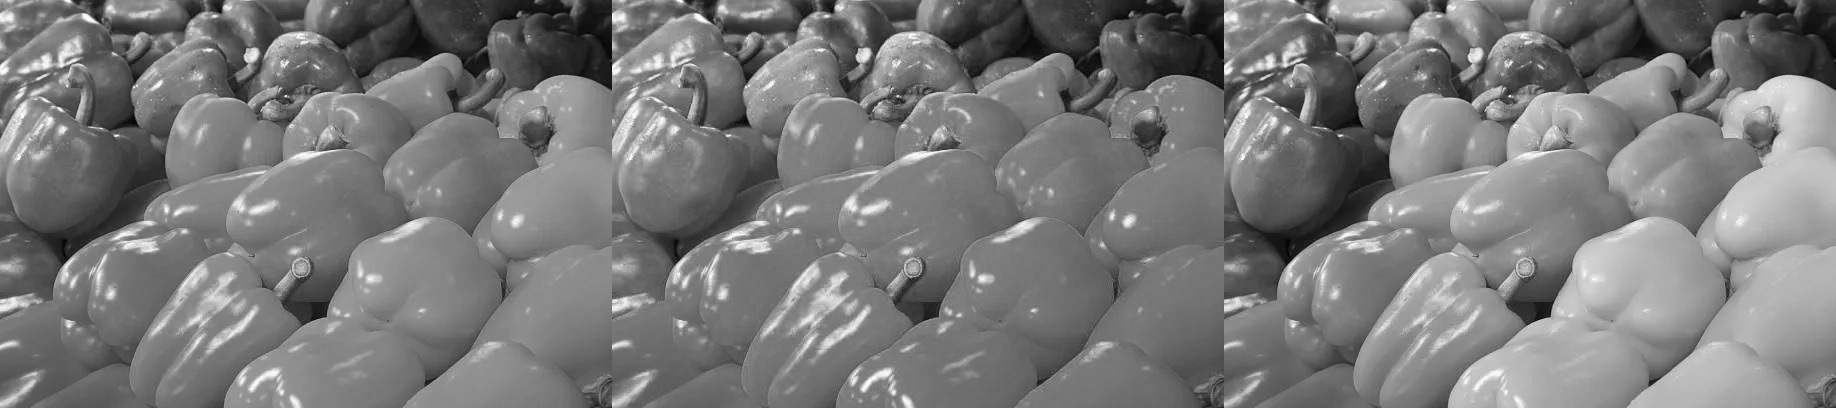

In [11]:
# 4. Grayscale Methods
img_peppers = cv.imread('/content/perfect-peppers.jpg')

if img_peppers is not None:
    img_bgr = img_peppers.astype(float)
    B, G, R = img_bgr[:,:,0], img_bgr[:,:,1], img_bgr[:,:,2]

    # a. Averaging
    gray_avg = ((R + G + B) / 3).astype(np.uint8)

    # b. Lightness
    gray_lightness = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

    # c. Luminance
    gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

    print('Tugas 4: Grayscale (Averaging | Lightness | Luminance)')
    cv2_imshow(np.hstack((gray_avg, gray_lightness, gray_luminance)))

Tugas 5: Isolasi Warna Merah


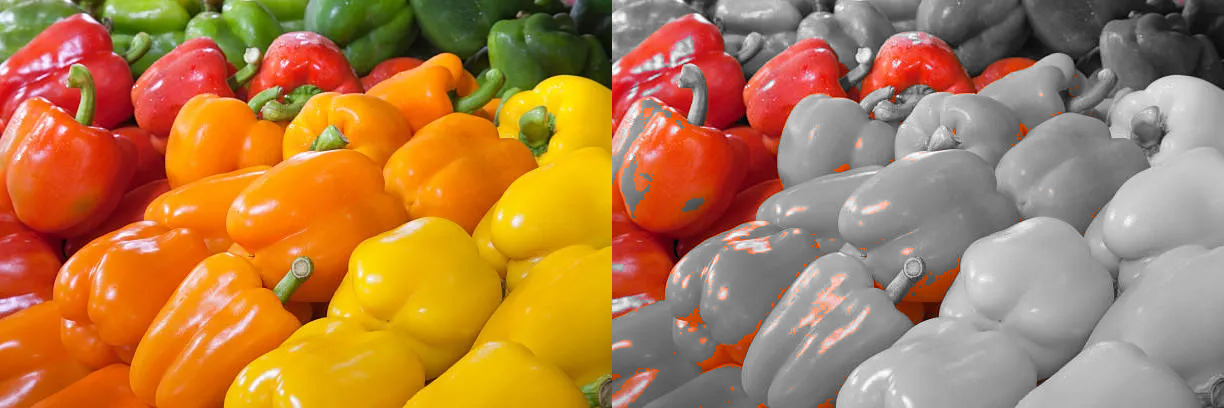

In [12]:
# 5. Warna Merah Tetap, Sisanya Grayscale
if img_peppers is not None:
    # Konversi ke ruang warna HSV untuk segmentasi warna merah
    hsv = cv.cvtColor(img_peppers, cv.COLOR_BGR2HSV)

    # Range warna merah 1 (merah bawah) & 2 (merah atas)
    lower_red1 = np.array([0, 50, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 50, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv.inRange(hsv, lower_red2, upper_red2)
    mask_red = mask1 | mask2

    # Buat versi grayscale 3-channel
    gray_base = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)
    gray_3ch = cv.cvtColor(gray_base, cv.COLOR_GRAY2BGR)

    # Terapkan masking
    red_only = np.where(mask_red[:, :, np.newaxis] == 255, img_peppers, gray_3ch)

    print('Tugas 5: Isolasi Warna Merah')
    cv2_imshow(np.hstack((img_peppers, red_only)))

Masukkan nilai Gamma (misal 0.5): 0.5
Tugas 6: Gamma Correction (gamma = 0.5)


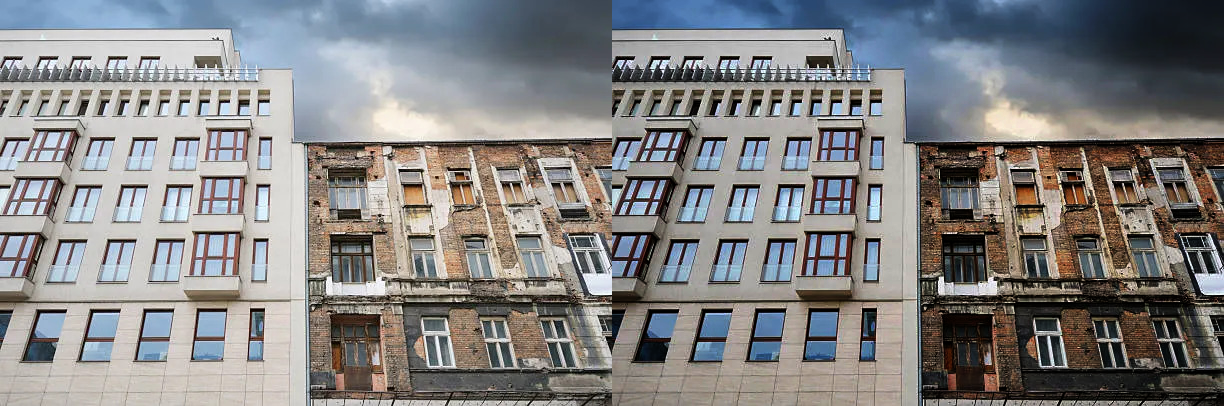

In [13]:
# 6. Gamma Correction
img_building = cv.imread('/content/buildings-century-apart.jpg')

if img_building is not None:
    try:
        gamma = float(input('Masukkan nilai Gamma (misal 0.5): '))

        # Menerapkan rumus Gamma Correction
        gamma_img = 255.0 * ((img_building.astype(float) / 255.0) ** (1.0 / gamma))
        gamma_img = np.clip(gamma_img, 0, 255).astype(np.uint8)

        print(f'Tugas 6: Gamma Correction (gamma = {gamma})')
        cv2_imshow(np.hstack((img_building, gamma_img)))
    except ValueError:
        print("Error: Input gamma harus berupa angka.")

Masukkan bit depth tujuan (1-7): 3
Tugas 7: Simulasi Bit Depth (3-bit)


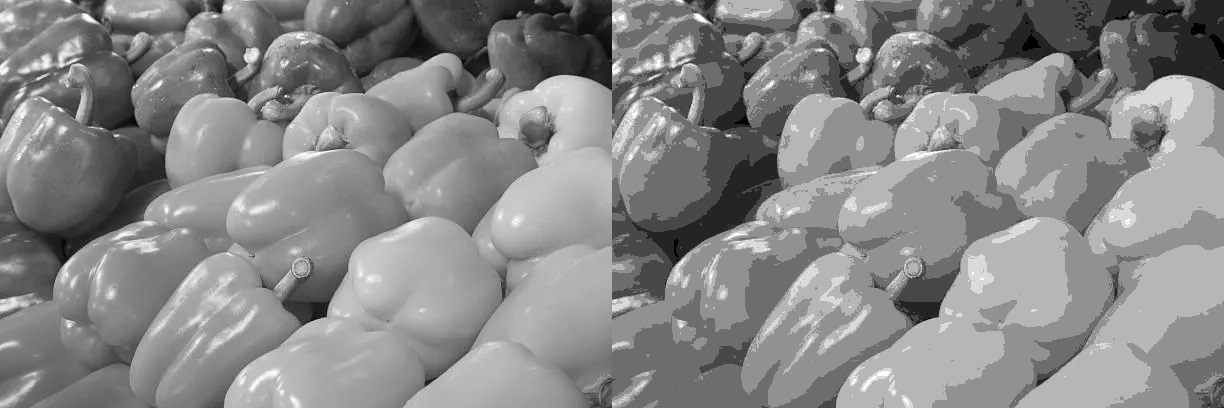

In [14]:
# 7. Image Depth Simulation
if img_peppers is not None:
    try:
        bit_depth = int(input('Masukkan bit depth tujuan (1-7): '))
        gray_img = cv.cvtColor(img_peppers, cv.COLOR_BGR2GRAY)

        # Hitung level rentang gradasi
        level = 255.0 / (pow(2, bit_depth) - 1)

        # Hitung kuantisasi warna baru
        depth_img = np.round(gray_img / level) * level
        depth_img = np.clip(depth_img, 0, 255).astype(np.uint8)

        print(f'Tugas 7: Simulasi Bit Depth ({bit_depth}-bit)')
        cv2_imshow(np.hstack((gray_img, depth_img)))
    except ValueError:
        print("Error: Input bit depth harus berupa angka bulat (1-7).")

--- Tabel Hasil Pengujian PSNR ---
No | Jumlah Citra | Nilai PSNR (dB)
-----------------------------------
 1 |           10 | 29.72 dB
 2 |           20 | 31.57 dB
 3 |           40 | 32.91 dB
 4 |           80 | 33.77 dB
 5 |          100 | 33.97 dB

Visualisasi Hasil (Original vs 100-Avg Denoised):


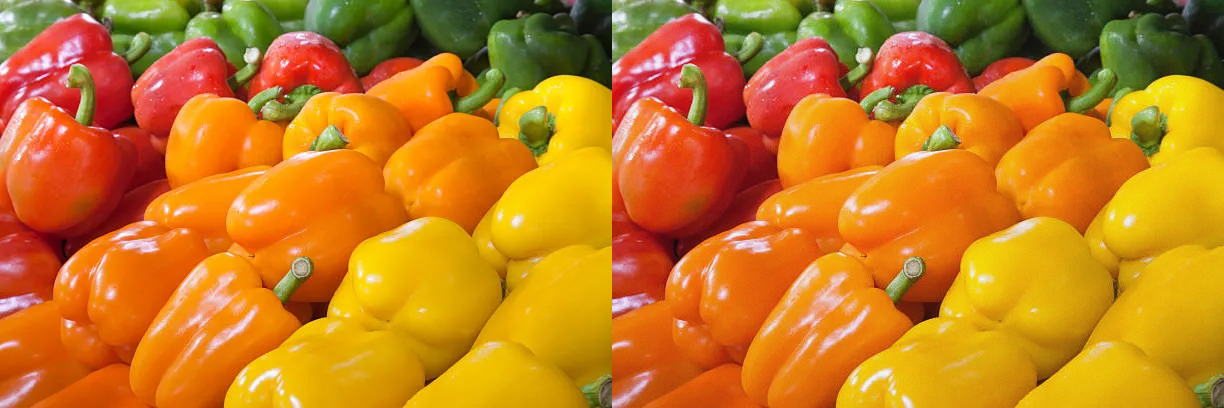

In [15]:
# 8. Average Denoising & Perhitungan PSNR
def calc_psnr(img1, img2):
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    if mse == 0:
        return 100.0
    return 20 * np.log10(255.0 / np.sqrt(mse))

# Menggunakan gambar asli sebagai referensi
base_img = cv.imread('/content/perfect-peppers.jpg')

if base_img is not None:
    # Menggenerasi 100 citra buatan yang diberi Gaussian Noise secara acak
    np.random.seed(42)
    noisy_images = [
        np.clip(base_img.astype(float) + np.random.normal(0, 25, base_img.shape), 0, 255).astype(np.uint8)
        for _ in range(100)
    ]

    counts = [10, 20, 40, 80, 100]
    print("--- Tabel Hasil Pengujian PSNR ---")
    print("No | Jumlah Citra | Nilai PSNR (dB)")
    print("-" * 35)

    for i, N in enumerate(counts, 1):
        # Hitung rata-rata tiap pixel sesuai jumlah citra N
        avg_img = np.mean(noisy_images[:N], axis=0).astype(np.uint8)
        psnr_val = calc_psnr(base_img, avg_img)
        print(f"{i:2d} | {N:12d} | {psnr_val:.2f} dB")

    print("\nVisualisasi Hasil (Original vs 100-Avg Denoised):")
    cv2_imshow(np.hstack((base_img, avg_img)))

Jawaban Pertanyaan & Kesimpulan Tugas 8:

- Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak. Pada awalnya (misalnya dari 10 ke 20 citra), peningkatan nilai PSNR terjadi secara signifikan. Namun, ketika jumlah citra makin banyak, peningkatannya melandai (diminishing returns).

- Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
Peningkatan mulai tidak terlalu signifikan saat jumlah citra mencapai kisaran 80 hingga 100 citra.

- Kesimpulan:
Metode averaging sangat efektif untuk menghilangkan random noise (seperti Gaussian noise) karena nilai rata-rata dari varians noise acak akan mendekati nol seiring bertambahnya sampel citra. Namun, terdapat titik jenuh di mana penambahan sampel citra tidak lagi memberikan kenaikan kualitas gambar secara drastis.

Hasil Masking Logic (AND | OR | XOR):


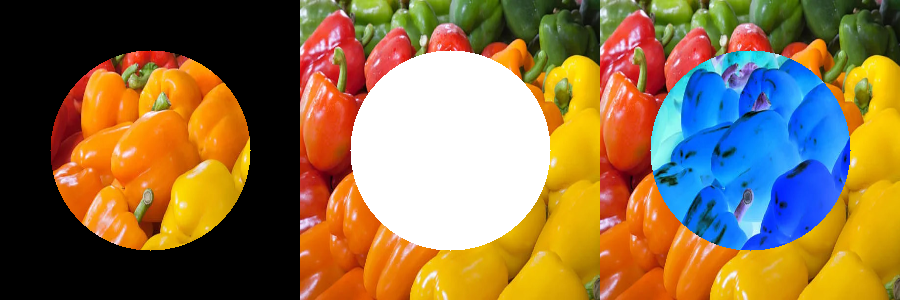

In [16]:
# 9. Image Masking dengan Operator Logika
img_src = cv.imread('/content/perfect-peppers.jpg')

if img_src is not None:
    img_src = cv.resize(img_src, (300, 300))

    # Membuat Mask Lingkaran Putih di atas Background Hitam
    mask = np.zeros((300, 300, 3), dtype=np.uint8)
    cv.circle(mask, (150, 150), 100, (255, 255, 255), -1)

    # Eksekusi Operator Logika
    res_not = cv.bitwise_not(img_src)
    res_and = cv.bitwise_and(img_src, mask)
    res_or = cv.bitwise_or(img_src, mask)
    res_nand = cv.bitwise_not(res_and)
    res_xor = cv.bitwise_xor(img_src, mask)

    print('Hasil Masking Logic (AND | OR | XOR):')
    cv2_imshow(np.hstack((res_and, res_or, res_xor)))

1. NOT (Komplemen)
Membalik seluruh nilai piksel ($255 - X$). Area terang menjadi gelap, dan area gelap menjadi terang (efek negatif).  
2. AND (Dan)
Hanya menampilkan piksel gambar asli di area dalam lingkaran putih mask ($X \land 255 = X$). Area luar lingkaran dipaksa menjadi hitam pekat ($X \land 0 = 0$).  
3. OR (Atau)
Mengubah seluruh area dalam lingkaran mask menjadi putih polos ($X \lor 255 = 255$). Area luar lingkaran tetap menampilkan gambar asli ($X \lor 0 = X$).  
4. NAND (Not AND)Kebalikan total dari operasi AND. Area luar lingkaran diubah menjadi putih polos, sedangkan area dalam lingkaran menampilkan citra negatif.
5. XOR (Exclusive OR)Membalik nilai warna piksel ($255 - X$) khusus di area dalam lingkaran mask, sementara area luar lingkaran tetap asli tanpa perubahan.

Tugas 10: Perbaikan Foto Malam Hari (Before vs After)


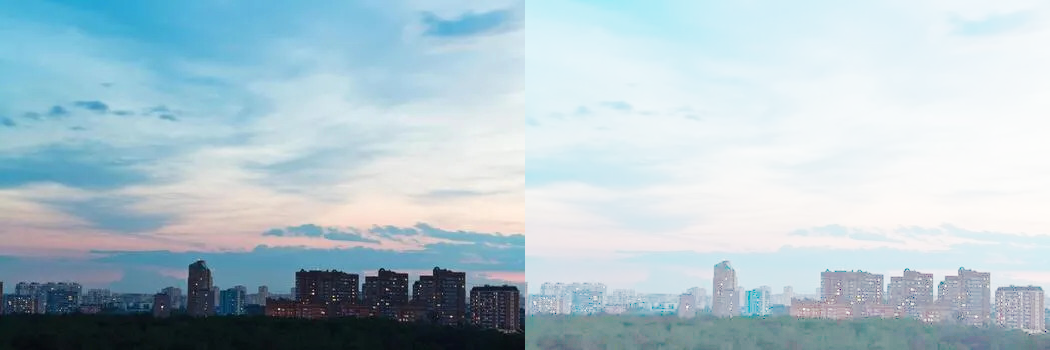

In [21]:
# 10. Perbaikan Foto Malam Hari
img_night = cv.imread('/content/durk-blue-and-pink-night-sky-over-city-photo.jpg') # Sesuaikan nama file

if img_night is not None:
    # Konversi ke float64 terlebih dahulu agar tidak overflow saat operasi matematika
    img_float = img_night.astype(np.float64)

    # Hitung nilai c secara aman dengan float64
    c_night = 255.0 / np.log(1.0 + np.max(img_float))

    # Terapkan transformasi Logarithmic Brightness
    night_enhanced = c_night * np.log(1.0 + img_float)
    night_enhanced = np.clip(night_enhanced, 0, 255).astype(np.uint8)

    print('Tugas 10: Perbaikan Foto Malam Hari (Before vs After)')
    cv2_imshow(np.hstack((img_night, night_enhanced)))
else:
    print("Error: File gambar tidak ditemukan!")

1. Metode yang Dipilih:
Transformasi Logarithmic Brightness ($s = c \times \log(1 + r)$).  

2. Alasan Pemilihan:
Foto malam hari dominan memiliki sebaran intensitas piksel (gray-level) pada rentang nilai rendah/gelap yang sangat sempit. Transformasi Logaritma berfungsi memetakan (mapping) rentang piksel gelap yang sempit tersebut menjadi skala warna yang jauh lebih lebar di citra keluaran. Hasilnya, detail area shadow atau bangunan di malam hari yang sebelumnya samar/gelap pekat dapat terlihat jauh lebih terang dan jelas tanpa membuat area yang sudah terang mengalami over-exposure.  

3. Risiko Metode:Penguatan Noise (Shadow Noise): Karena area piksel gelap ditarik/dinaikkan intensitasnya secara drastis, noise acak (seperti grain atau sensor noise) yang mengendap di area gelap juga ikut terekspos dan terlihat semakin jelas.Penurunan Kontras Alami: Warna latar belakang malam hari (seperti langit hitam) bisa berubah agak keabu-abuan sehingga citra kehilangan kesan kontras alami antara siang dan malam hari.

Tugas 11: Perbaikan Citra Crayfish (Before vs After)


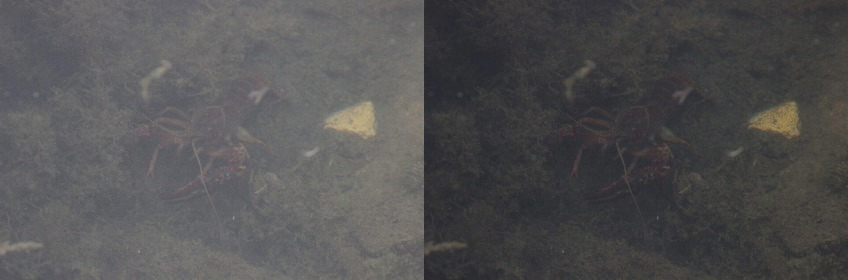

In [23]:
# 11. Perbaikan Citra Crayfish
img_crayfish = cv.imread('/content/crafish.jpeg')

if img_crayfish is not None:
    # Step 1: Gamma Correction (gamma = 0.6) untuk mencerahkan midtone
    gamma_step = 255.0 * ((img_crayfish.astype(np.float64) / 255.0) ** (1.0 / 0.6))

    # Step 2: Contrast Enhancement (C = 1.3) untuk mempertegas objek
    contrast_val = 1.3
    factor = (259.0 * (contrast_val + 255.0)) / (255.0 * (259.0 - contrast_val))
    crayfish_enhanced = factor * (gamma_step - 128.0) + 128.0
    crayfish_enhanced = np.clip(crayfish_enhanced, 0, 255).astype(np.uint8)

    print('Tugas 11: Perbaikan Citra Crayfish (Before vs After)')
    cv2_imshow(np.hstack((img_crayfish, crayfish_enhanced)))
else:
    print("Error: File /content/crafish.jpeg tidak ditemukan! Cek kembali nama filenya di sidebar Files.")

- Metode yang Dipilih:
Kombinasi Gamma Correction ($\gamma = 0.6$) dan Transformasi Contrast ($C = 1.3$).  

- Alasan Pemilihan:
Citra crafish.jpeg memiliki kualitas visual yang pudar, underexposed, dan kontrasnya rendah.  Gamma Correction digunakan untuk mencerahkan area midtone dan bagian gelap secara logaritmik tanpa membuat area terang menjadi overexposed.  Transformasi Contrast diaplikasikan untuk memperlebar sebaran histogram, sehingga batas bentuk tubuh dan tekstur crayfish menjadi lebih tajam serta terpisah jelas dari latar belakang airnya.  

- Menentukan Parameter Terbaik:Gamma ($\gamma = 0.6$): Mencerahkan citra dengan pas. Jika gamma terlalu kecil ($< 0.4$), citra akan terlalu putih/pudar (washed out).Contrast Factor ($C = 1.3$): Mempertegas detail objek. Jika kontras terlalu tinggi ($> 2.0$), warna piksel terang akan mengalami clipping/truncate (menjadi putih pekat 255).  